# FDA 이상사례 데이터 - ATC B코드, B군(철분제/Ferrous sulfate) 인사이트 분석

전체 FDA 이상사례 보고 데이터 중 ATC 1단계 코드 B(Blood and blood forming organs, 혈액 및 조혈기관용제)
의약품을 엽산제(A) / 철분제(B) / 복합 미네랄제(C)로 재분류했을 때, 이 중 B군(철분제, 도출_ATC코드 ==
"B03AA07", 성분 Ferrous sulfate)에 대해서만 아래 항목을 분석합니다.

B군은 26건(제공 이미지 기준 25건, 26.6%와 근사)으로, 지금까지 분석한 노트북 중 표본이 가장 작습니다
(리도카인 155건, 디클로페낙 260건, 비강 스테로이드 40건). 그래서 이번에도 두 갈래로 구성합니다.

- 데이터로 답할 수 있는 부분은 통계 검정과 함께 분석하되, 표본이 작아 검정력이 낮다는 한계를 매번 명시합니다.
  검정이 유의하지 않아 시각화가 오히려 오해를 줄 수 있는 항목은 차트를 생략하고 수치만 보고합니다.
- 데이터만으로는 근거가 약하거나 건수가 너무 적은 위험 신호(특히 소아 우발적 철분제 중독)는 별도
  섹션(12번)에서 관련 의학 문헌을 찾아 출처(PubMed 링크 포함)와 함께 보완합니다.

1. B군 정의 확인 (건수 검증)
2. 인체 특성 (연령.성별)
3. 심각도 (사망.입원.생명위협.장애.회복여부)
4. 병용 약물 수 (다제복용)
5. 투약 사유(적응증)
6. 이상반응 유형
7. 전체 반응(reactions) 분해
8. 급성 철분 중독(과다복용) 신호 - 데이터 + 문헌
9. 참조표(FDA 라벨) 안전정보 대비 실제 신고 성향
10. 심각도(serious)와 인체특성·병용약물의 관계 (표본 한계 포함)
11. 같은 ATC코드(B) 내 비교 - 철분제 vs 엽산제
12. 문헌 기반 보완 분석 - 라벨의 소아 중독 경고와 실제 데이터의 격차
13. 종합 인사이트 요약
14. 소비자를 위한 요약 - 이 약을 복용하기 전에 알아둘 점

비교 기준선은 B군을 제외한 전체 데이터(나머지 전체, Rest)로 설정합니다.

(※ 시계열/브랜드·제조사 기반 분석은 제외했습니다 - quarter는 FDA 보고서 "접수일" 기준이라 실제 발생 시점을
반영하지 못하고, 브랜드·제조사별 보고 건수/비율도 실사용량 등 노출 분모가 없어 위험도 비교로 쓰기 어렵기 때문입니다.)

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
candidates = ["AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"]
available = {f.name for f in fm.fontManager.ttflist}
kfont = next((c for c in candidates if c in available), None)
if kfont:
    plt.rcParams["font.family"] = kfont
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

In [2]:
# 색상 팔레트 (범주형 고정 순서 + 상태색)
C1_BLUE, C2_AQUA, C3_YELLOW, C4_GREEN = "#2a78d6", "#1baf7a", "#eda100", "#008300"
C5_VIOLET, C6_RED, C7_MAGENTA, C8_ORANGE = "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"
MUTED, GRID, INK, INK2 = "#898781", "#e1e0d9", "#0b0b0b", "#52514e"
STATUS_CRIT = "#d03b3b"

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(colors=INK2, labelsize=9)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title, fontsize=12, color=INK, fontweight="bold", pad=10)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=9.5, color=INK2)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=9.5, color=INK2)

def p_str(x):
    return "p < 0.001" if x < 0.001 else "p = {:.3f}".format(x)

## 데이터 로드 및 B군(철분제) 정의

In [3]:
DATA_PATH = "FDA_adverse_events_final_참조표병합.csv"  # 노트북과 같은 폴더에 위치

df = pd.read_csv(DATA_PATH, low_memory=False)
df["age_num"] = pd.to_numeric(df["patient_age_years"], errors="coerce")
df["weight_num"] = pd.to_numeric(df["patient_weight_kg"], errors="coerce")

# 코드 B(혈액 및 조혈기관용제) 전체 및 세부 그룹
b_all = df[df["도출_ATC코드"].astype(str).str.startswith("B")].copy()
print("코드 B(혈액 및 조혈기관용제) 전체 건수:", f"{len(b_all):,}")
print(b_all["도출_ATC코드"].value_counts())
print()

# B군 = 철분제(Ferrous sulfate), ATC 도출코드 B03AA07
is_B = df["도출_ATC코드"] == "B03AA07"
b = df[is_B].copy()
rest = df[~is_B].copy()

print(f"B군(철분제) 건수: {len(b):,}  (참고: 제공 이미지 기준 25건, 26.6% - 근사)")
print(f"B군 비중(코드 B 내): {len(b)/len(b_all)*100:.1f}%")
print(f"B군 대표 성분: {b['참조_영문성분명'].unique()}")
print(f"나머지 전체(Rest) 건수: {len(rest):,}")
print()
b_serious_pct = (b['serious']=='Yes').mean()*100
rest_serious_pct = (rest['serious']=='Yes').mean()*100
print(f"B군 심각(serious) 비율: {b_serious_pct:.1f}%  (n=26 중 25건)")
print(f"B군 사망(fatal) 비율: {b['is_fatal'].mean()*100:.1f}%  (n=26 중 2건)")
print(f"나머지 전체(Rest) 심각 비율: {rest_serious_pct:.1f}%")
print()
print("주의: B군은 n=26으로, 지금까지 분석한 성분 중 표본이 가장 작습니다. 특히 serious=No가 단 1건뿐이라")
print("      '심각도와 다른 변수의 관계' 분석은 통계적으로 사실상 불가능합니다(9번 섹션 참고).")

코드 B(혈액 및 조혈기관용제) 전체 건수: 95
도출_ATC코드
B03BB01    69
B03AA07    26
Name: count, dtype: int64

B군(철분제) 건수: 26  (참고: 제공 이미지 기준 25건, 26.6% - 근사)
B군 비중(코드 B 내): 27.4%
B군 대표 성분: ['Ferrous sulfate']
나머지 전체(Rest) 건수: 18,247

B군 심각(serious) 비율: 96.2%  (n=26 중 25건)
B군 사망(fatal) 비율: 7.7%  (n=26 중 2건)
나머지 전체(Rest) 심각 비율: 85.5%

주의: B군은 n=26으로, 지금까지 분석한 성분 중 표본이 가장 작습니다. 특히 serious=No가 단 1건뿐이라
      '심각도와 다른 변수의 관계' 분석은 통계적으로 사실상 불가능합니다(9번 섹션 참고).


## 1. 인체 특성 (연령 · 성별)

In [4]:
# 연령 분포 차트는 생략 - 연령 확인 가능 건수가 17/26건뿐이고 검정도 유의하지 않아(아래 참고)
# 시각화보다 수치 확인이 더 정확함
age_b = b["age_num"].dropna()
age_rest = rest["age_num"].dropna()

u_age, p_age = stats.mannwhitneyu(age_b, age_rest, alternative="two-sided")
print(f"[연령] Mann-Whitney U 검정: U={u_age:.0f}, {p_str(p_age)}  (B군 중앙값 {age_b.median():.0f}세(n={len(age_b)}/26) vs Rest 중앙값 {age_rest.median():.0f}세)")
print("  → 유의하지 않음 - n=26(연령 확인 가능 17건)으로는 나머지 전체와 연령 분포 차이를 확정할 수 없음")
print()

ag_order = ["Teen(13-18)", "Middle-Aged(41-65)", "Senior(66-80)", "Elderly(81+)", "Unknown"]
ag_labels = ["10대", "중년", "노년", "고령", "미상"]
b_ag = b["age_group"].value_counts().reindex(ag_order).fillna(0).astype(int)
print("B군 연령대 분포(건수):")
print(b_ag)
print("→ 20대~30대(Adult) 및 영유아·소아 표본이 전혀 없음 - 중년 이후 연령대(빈혈 치료 목적)에 집중")

[연령] Mann-Whitney U 검정: U=130661, p = 0.194  (B군 중앙값 66세(n=17/26) vs Rest 중앙값 60세)
  → 유의하지 않음 - n=26(연령 확인 가능 17건)으로는 나머지 전체와 연령 분포 차이를 확정할 수 없음

B군 연령대 분포(건수):
age_group
Teen(13-18)           2
Middle-Aged(41-65)    6
Senior(66-80)         6
Elderly(81+)          3
Unknown               9
Name: count, dtype: int64
→ 20대~30대(Adult) 및 영유아·소아 표본이 전혀 없음 - 중년 이후 연령대(빈혈 치료 목적)에 집중


In [5]:
# 성별 비교 차트도 생략 - n=26으로는 통계적 비교가 무의미, 수치만 확인
b_female_pct = (b['patient_sex']=='Female').mean()*100
rest_female_pct = (rest['patient_sex']=='Female').mean()*100
print(b["patient_sex"].value_counts())
print(f"\nB군 여성 비율 {b_female_pct:.1f}%(17/26) vs Rest {rest_female_pct:.1f}% - 철결핍성 빈혈 자체가")
print("여성(특히 가임기·임신)에서 더 흔하다는 임상적 배경과 부합하는 방향이나, n=26으로 확정할 수는 없음")
print()

w_b = b['weight_num'].dropna()
print(f"[체중] 결측 아닌 값: {len(w_b)}/{len(b)}건뿐 - 분석에 사용하기엔 표본이 너무 작아 생략")

patient_sex
Female     17
Male        6
Unknown     3
Name: count, dtype: int64

B군 여성 비율 65.4%(17/26) vs Rest 49.7% - 철결핍성 빈혈 자체가
여성(특히 가임기·임신)에서 더 흔하다는 임상적 배경과 부합하는 방향이나, n=26으로 확정할 수는 없음

[체중] 결측 아닌 값: 6/26건뿐 - 분석에 사용하기엔 표본이 너무 작아 생략


## 2. 심각도 (사망·입원·생명위협·장애·회복여부)

/tmp/ipykernel_2244/2419511149.py:17: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/2419511149.py:17: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/2419511149.py:17: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/2419511149.py:17: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/2419511149.py:17: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/2419511149.py:17: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/2419511149.py:17: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tig

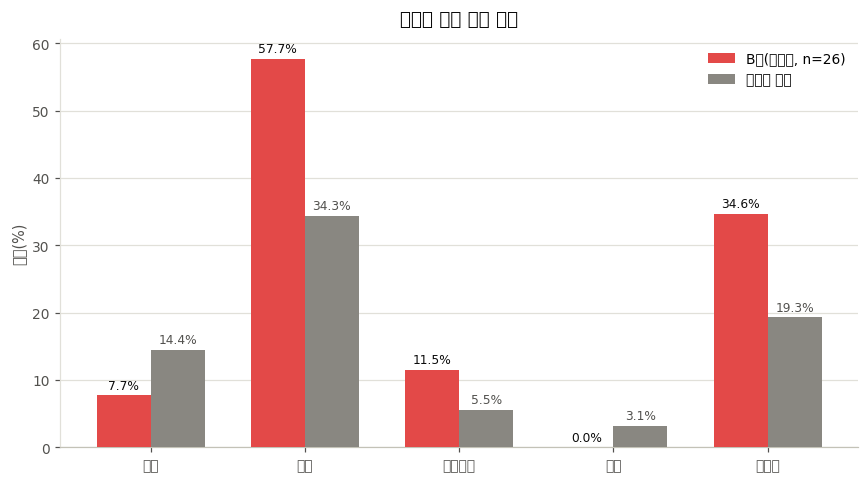

[B군 vs Rest] Chi-square 독립성 검정 (각 심각도 지표, n=26이라 검정력 낮음에 유의):
  - 사망    : B군   7.7% vs Rest  14.4%  |  chi2=   0.5, p = 0.484
  - 입원    : B군  57.7% vs Rest  34.3%  |  chi2=   5.3, p = 0.022
  - 생명위협  : B군  11.5% vs Rest   5.5%  |  chi2=   0.8, p = 0.363
  - 장애    : B군   0.0% vs Rest   3.1%  |  chi2=   0.1, p = 0.722
  - 회복됨   : B군  34.6% vs Rest  19.3%  |  chi2=   3.0, p = 0.084

→ 입원 비율(57.7% vs 34.3%)은 유일하게 통계적으로 유의함(p=0.022) - 나머지 지표는 표본이 작아
  유의성에 도달하지 못했지만, 입원 비율만큼은 철분제가 나머지 전체보다 뚜렷이 높다고 볼 수 있음

[B군 내부] serious_flags 세부 내역:
serious_flags
Hospitalization                      11
Unknown                              10
Hospitalization; Life-Threatening     3
Death                                 1
Death; Hospitalization                1
Name: count, dtype: int64


In [6]:
sev_cols = ["is_fatal", "is_hospitalized", "is_life_threat", "is_disabling", "patient_recovered"]
sev_labels = ["사망", "입원", "생명위협", "장애", "회복됨"]

b_rate = [b[col].mean() * 100 for col in sev_cols]
rest_rate = [rest[col].mean() * 100 for col in sev_cols]

fig, ax = plt.subplots(figsize=(8, 4.5))
x = np.arange(len(sev_cols)); w = 0.35
ax.bar(x - w/2, b_rate, w, label="B군(철분제, n=26)", color=C6_RED, zorder=3)
ax.bar(x + w/2, rest_rate, w, label="나머지 전체", color=MUTED, zorder=3)
ax.set_xticks(x); ax.set_xticklabels(sev_labels)
style_ax(ax, "심각도 지표 비율 비교", None, "비율(%)")
ax.legend(frameon=False, fontsize=9)
for xi, (bv, rv) in enumerate(zip(b_rate, rest_rate)):
    ax.text(xi - w/2, bv + 1, f"{bv:.1f}%", ha="center", fontsize=8, color=INK)
    ax.text(xi + w/2, rv + 1, f"{rv:.1f}%", ha="center", fontsize=8, color=INK2)
plt.tight_layout()
plt.show()

print("[B군 vs Rest] Chi-square 독립성 검정 (각 심각도 지표, n=26이라 검정력 낮음에 유의):")
for col, lab in zip(sev_cols, sev_labels):
    ct = pd.crosstab(df["도출_ATC코드"].eq("B03AA07"), df[col])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    print(f"  - {lab:6s}: B군 {b[col].mean()*100:5.1f}% vs Rest {rest[col].mean()*100:5.1f}%  |  chi2={chi2:6.1f}, {p_str(p)}")

print()
print("→ 입원 비율(57.7% vs 34.3%)은 유일하게 통계적으로 유의함(p=0.022) - 나머지 지표는 표본이 작아")
print("  유의성에 도달하지 못했지만, 입원 비율만큼은 철분제가 나머지 전체보다 뚜렷이 높다고 볼 수 있음")

print("\n[B군 내부] serious_flags 세부 내역:")
print(b["serious_flags"].value_counts())

## 3. 병용 약물 수 (다제복용)

In [7]:
# 병용약물수 구간/분포 차트도 생략 - 아래 Mann-Whitney U 검정이 유의하지 않음(p=0.374)
u_nd, p_nd = stats.mannwhitneyu(b["num_drugs"], rest["num_drugs"], alternative="two-sided")
print(f"[병용 약물 수] Mann-Whitney U 검정: U={u_nd:.0f}, {p_str(p_nd)}  (유의하지 않음)")
print(f"  B군 중앙값 {b['num_drugs'].median():.1f}종 (평균 {b['num_drugs'].mean():.2f}, 최댓값 {b['num_drugs'].max():.0f}) vs "
      f"Rest 중앙값 {rest['num_drugs'].median():.0f}종 (평균 {rest['num_drugs'].mean():.2f}, 최댓값 {rest['num_drugs'].max():.0f})")
print(b["drug_count_category"].value_counts())

[병용 약물 수] Mann-Whitney U 검정: U=213374, p = 0.374  (유의하지 않음)
  B군 중앙값 6.5종 (평균 10.81, 최댓값 42) vs Rest 중앙값 9종 (평균 17.81, 최댓값 2108)
drug_count_category
Polypharmacy(6+)    13
4-5 Drugs            5
2-3 Drugs            4
Single               4
Name: count, dtype: int64


## 4. 투약 사유 (적응증, drug_indication)

/tmp/ipykernel_2244/761360524.py:6: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/761360524.py:6: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/761360524.py:6: UserWarning: Glyph 44400 (\N{HANGUL SYLLABLE GUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/761360524.py:6: UserWarning: Glyph 52384 (\N{HANGUL SYLLABLE CEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/761360524.py:6: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/761360524.py:6: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/761360524.py:6: UserWarning: Glyph 53804 (\N{HANGUL SYLLABLE TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ip

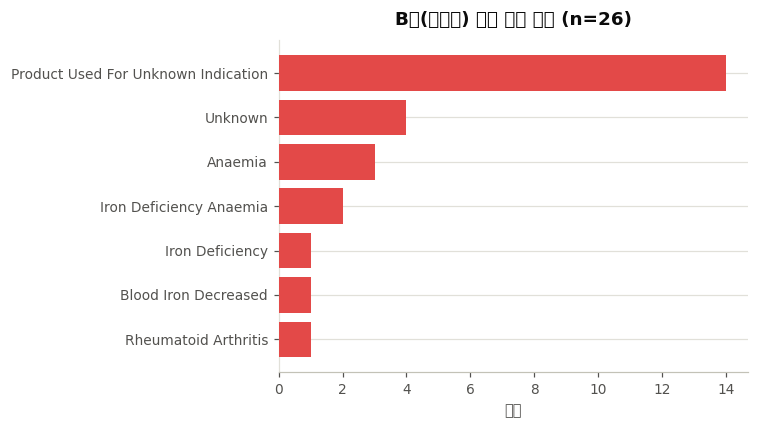

drug_indication
Product Used For Unknown Indication    14
Unknown                                 4
Anaemia                                 3
Iron Deficiency Anaemia                 2
Iron Deficiency                         1
Blood Iron Decreased                    1
Rheumatoid Arthritis                    1
Name: count, dtype: int64

빈혈/철결핍 관련 적응증 명시: 6건 - 나머지는 '적응증 미기재'(14건)로, 철분제가
  건강기능식품처럼 인식되어 처방 사유 없이 자가 복용되는 경우가 많음을 시사


In [8]:
top_ind = b["drug_indication"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(top_ind.index[::-1], top_ind.values[::-1], color=C6_RED, zorder=3)
style_ax(ax, f"B군(철분제) 투약 사유 전체 (n={len(b)})", "건수", None)
plt.tight_layout()
plt.show()

print(top_ind)

anaemia_n = b['drug_indication'].str.contains('Anaemia|Anemia|Iron Deficiency', case=False, na=False).sum()
print(f"\n빈혈/철결핍 관련 적응증 명시: {anaemia_n}건 - 나머지는 '적응증 미기재'(14건)로, 철분제가")
print("  건강기능식품처럼 인식되어 처방 사유 없이 자가 복용되는 경우가 많음을 시사")

## 5. 이상반응 유형 (primary_reaction)

In [9]:
# 대표 반응이 거의 전부 1건씩이라(26건 중 2건 이상인 항목이 2개뿐) 막대그래프 대신 표로 확인
top_rx = b["primary_reaction"].value_counts()
print(f"B군(n={len(b)}) 대표 반응 - 서로 다른 반응 {top_rx.shape[0]}종")
print(top_rx)
print()
print("→ '완결된 자살(Completed suicide)'과 '의도적 과다복용(Intentional overdose)'이 각 1건씩 대표")
print("  반응으로 등장 - 일반적인 영양보충제에서는 드문 패턴. 7번 섹션에서 상세 확인")

B군(n=26) 대표 반응 - 서로 다른 반응 24종
primary_reaction
Iron deficiency anaemia                   2
Oxygen saturation decreased               2
Completed suicide                         1
Chest injury                              1
Gastrointestinal haemorrhage              1
Incorrect route of drug administration    1
Intentional overdose                      1
Deformity                                 1
Gastritis                                 1
Hunger                                    1
Nausea                                    1
Drug interaction                          1
Drug hypersensitivity                     1
Agitation                                 1
Pica                                      1
Pain                                      1
Diarrhoea haemorrhagic                    1
Malaise                                   1
Condition aggravated                      1
Impaired healing                          1
Respiratory tract ulceration              1
Duodenitis                   

## 6. 전체 반응(reactions) 분해

/tmp/ipykernel_2244/3302908171.py:14: UserWarning: Glyph 50616 (\N{HANGUL SYLLABLE EON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/3302908171.py:14: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/3302908171.py:14: UserWarning: Glyph 54943 (\N{HANGUL SYLLABLE HOES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/3302908171.py:14: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/3302908171.py:14: UserWarning: Glyph 44400 (\N{HANGUL SYLLABLE GUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/3302908171.py:14: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/3302908171.py:14: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_

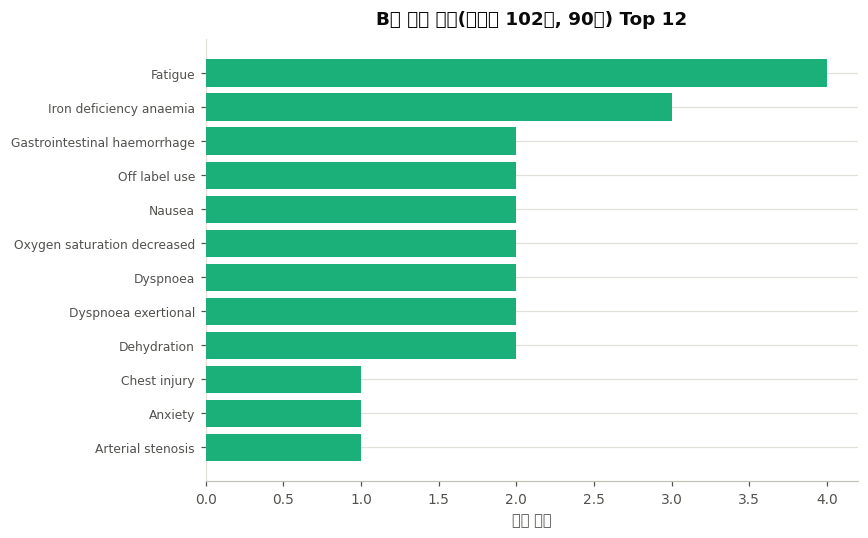

보고서 26건에서 총 102건의 개별 반응 언급 (건당 평균 3.92개, 90종의 서로 다른 반응)

[위장관 부식/천공 계열 키워드] 4건 - 급성 철 중독의 전형적 소견(7번 섹션에서 심층 확인)
[다장기부전 키워드] 1건


In [10]:
from collections import Counter

react_lists = b["reactions"].fillna("").apply(lambda s: [x.strip() for x in s.split(";") if x.strip()])
all_react = [r for lst in react_lists for r in lst]
react_counter = Counter(all_react)
top12 = react_counter.most_common(12)

fig, ax = plt.subplots(figsize=(8, 5))
labels = [t[0] for t in top12][::-1]
values = [t[1] for t in top12][::-1]
ax.barh(labels, values, color=C2_AQUA, zorder=3)
style_ax(ax, f"B군 전체 반응(연인원 {len(all_react)}건, {len(react_counter)}종) Top 12", "언급 횟수", None)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

avg_react = len(all_react) / len(b)
print(f"보고서 {len(b)}건에서 총 {len(all_react)}건의 개별 반응 언급 (건당 평균 {avg_react:.2f}개, {len(react_counter)}종의 서로 다른 반응)")
print()

gi_kw = ["perforation", "pneumoperitoneum", "ulceration", "duodenitis", "gastritis"]
text_all = b["reactions"].fillna("").str.lower()
gi_mask = text_all.str.contains("|".join(gi_kw), na=False)
print(f"[위장관 부식/천공 계열 키워드] {gi_mask.sum()}건 - 급성 철 중독의 전형적 소견(7번 섹션에서 심층 확인)")

organ_mask = text_all.str.contains("multiple organ dysfunction|organ failure", na=False)
print(f"[다장기부전 키워드] {organ_mask.sum()}건")

## 7. 급성 철분 중독(과다복용) 신호 - 데이터 + 문헌

In [11]:
# 도메인 지식: 철분제는 소량만 과다복용해도 위장관 부식, 대사성 산증, 간독성, 다장기부전으로 이어질 수
# 있는 대표적인 급성 중독 위험 약물입니다. 실제 데이터에서 이런 신호가 있는지 개별 사례를 확인
text_full = (b["reactions"].fillna("") + " " + b["primary_reaction"].fillna("")).str.lower()
od_kw = ["overdose", "suicide", "incorrect route", "toxicity to various agents"]
od_mask = text_full.str.contains("|".join(od_kw), na=False)
od = b[od_mask]

print(f"과다복용/중독 관련 키워드 포함 보고: {len(od)}건 / B군 전체 {len(b)}건")
print(od[["patient_age_years", "age_group", "patient_sex", "drug_indication", "primary_reaction", "is_fatal", "is_hospitalized", "is_life_threat", "country"]].to_string())
print()

child_mask = b["age_group"].isin(["Infant(0-2)", "Child(3-12)"])
print(f"[소아(12세 이하) 표본 수] {child_mask.sum()}건 / B군 전체 {len(b)}건")
print()
print("→ 이 데이터에는 라벨이 명시적으로 경고하는 '6세 미만 소아의 우발적 다량 섭취' 사례가 단 1건도")
print("  없습니다. 그러나 이것이 '소아는 안전하다'는 뜻은 아닙니다 - 최소 세 가지 다른 설명이 가능하며,")
print("  이 데이터만으로는 어느 쪽인지 구분할 수 없습니다.")
print("  (1) 라벨 경고·안전 보관 문화 덕분에 실제 사고 자체가 줄었을 가능성")
print("  (2) 소아의 우발적 섭취는 보통 중독관리센터(Poison Control)로 먼저 신고되는데, 이 데이터는")
print("      FDA 약물 이상사례 보고(FAERS) 시스템이라 두 시스템이 달라 구조적으로 안 잡혔을 가능성")
print("  (3) 26건이라는 매우 작은 표본 크기상 우연히 포함되지 않았을 가능성")
print()
print("  대신 이 표본 안에서 \"실제로 확인되는\" 중증 사례는 (1) 59세 성인의 투여경로 오류로 인한")
print("  과다복용(입원·생명위협), (2) 16세 청소년의 의도적 과다복용(자살시도, 급성 간부전으로 간이식까지")
print("  진행), (3) 16세 청소년의 독성 반응으로 인한 다발성 장기부전·장천공·사망(B군 유일한 사망 사례)")
print("  입니다. 이는 \"청소년·성인의 오남용이 이 표본에 존재한다\"는 사실일 뿐, \"소아 위험이 상대적으로")
print("  작다\"는 근거가 되지는 않습니다 - 소아 우발 중독은 문헌상 여전히 잘 알려진 위험입니다.")
print()
print("[문헌 근거]")
print()
print("- 철분제는 소아에서 '단 몇 알로도 사망할 수 있는' 대표적 약물 중 하나로 오랫동안 응급의학·독성학")
print("  문헌에서 다뤄져 왔습니다.")
print("  Michael JB, Sztajnkrycer MD. \"Deadly pediatric poisons: nine common agents that kill at low")
print("  doses.\" Emerg Med Clin North Am. 2004;22(4):1019-1050. PMID 15474780.")
print("  https://pubmed.ncbi.nlm.nih.gov/15474780/")
print()
print("- 1983~1991년 사이 소아의 철분제 섭취 신고가 2~3배 늘었고, 노출 100건당 사망률도")
print("  1983-1990년 0.05에서 1991년 0.116으로 증가했다는 미국 자료가 있습니다(당시 처방량 증가는")
print("  16%에 불과해, 처방약보다 OTC 철분제 사용 증가가 주된 원인으로 지목됨).")
print("  Berkovitch M, Matsui D, Lamm SH, Rosa F, Koren G. \"Recent increases in numbers and risk of")
print("  fatalities in young children ingesting iron preparations.\" Vet Hum Toxicol. 1994;36(1):53-56.")
print("  PMID 8154104. https://pubmed.ncbi.nlm.nih.gov/8154104/")
print()
print("- 이런 배경에서 미국은 1997년 철분 함유 제품에 개별 포장(unit-dose packaging)을 의무화했고,")
print("  그 이후 소아 철분 섭취·사망이 줄었다는 분석이 있습니다. 다만 2003년 이 규정은 소송(건강기능식품")
print("  업계가 FDA의 관할권을 문제 삼음) 끝에 철회되었습니다 - 즉 이 데이터에 소아 사례가 없는 것을")
print("  '포장 규제 덕분'으로 단순히 해석하기보다, 규제의 역사 자체가 유동적이었다는 점도 함께 봐야 합니다.")
print("  Tenenbein M. \"Unit-dose packaging of iron supplements and reduction of iron poisoning in young")
print("  children.\" Arch Pediatr Adolesc Med. 2005;159(6):557-560. PMID 15939855.")
print("  https://pubmed.ncbi.nlm.nih.gov/15939855/")
print()
print("- 급성 철 중독의 임상 경과는 크게 3~5단계로 알려져 있습니다: (1)위장관 부식·출혈로 시작해,")
print("  (2)겉보기에 호전된 것처럼 보이는 잠복기를 거쳐, (3)이후 대사성 산증·쇼크·간독성·다장기부전으로")
print("  진행할 수 있습니다. 기전적으로는 철 이온이 미토콘드리아에 축적되어 산화적 인산화를 방해하고")
print("  자유라디칼·지질과산화를 유발하는 것이 핵심입니다.")
print("  NCBI StatPearls. \"Iron Toxicity.\" https://www.ncbi.nlm.nih.gov/books/NBK459224/")
print("  이 데이터의 16세 사망 사례(장천공·복막 내 공기·다발성 장기부전)는 이 임상 경과와 상당히")
print("  일치하는 패턴입니다.")

과다복용/중독 관련 키워드 포함 보고: 4건 / B군 전체 26건
      patient_age_years           age_group patient_sex                      drug_indication                        primary_reaction  is_fatal  is_hospitalized  is_life_threat country
18179              59.0  Middle-Aged(41-65)      Female  Product Used For Unknown Indication                       Completed suicide      True            False           False      US
18183              59.0  Middle-Aged(41-65)      Female                      Iron Deficiency  Incorrect route of drug administration     False             True            True      AU
18184              16.0         Teen(13-18)      Female  Product Used For Unknown Indication                    Intentional overdose     False             True            True      US
18197              16.0         Teen(13-18)     Unknown  Product Used For Unknown Indication                  Diarrhoea haemorrhagic      True             True           False      US

[소아(12세 이하) 표본 수] 0건 / B군 전체 26건

→ 이 데이터에

## 8. 참조표(FDA 라벨) 안전정보 대비 실제 신고 성향

In [12]:
ref_cols = ["참조_최대용량_기간제한", "참조_절대금기(do_not_use)", "참조_즉시중단_신호(stop_use)",
            "참조_임부_수유부_주의", "참조_기타주의사항"]
print("[B군 성분의 FDA 라벨 참조 정보] (성분 단일이므로 26건 모두 동일)")
for col in ref_cols:
    print(f"- {col}: {b[col].iloc[0]}")

print()
print("→ '참조_기타주의사항'에 이미 '소아(6세 미만)의 우발적 과다복용은 치명적 중독의 주요 원인'이라는")
print("  박스경고(Boxed Warning)급 문구가 명시되어 있습니다. 그런데 7번 섹션에서 확인했듯 이 데이터에는")
print("  정작 그 연령대 사례가 없고, 대신 청소년·성인의 과다복용이 확인됩니다 - 다만 이는 소아 위험이")
print("  작다는 뜻이 아니라 이 표본/데이터 소스의 한계일 수 있습니다. 이 격차는 11번 섹션에서 더 다룹니다.")
print()

text_cols = b['reactions'].fillna('') + ' ' + b['primary_reaction'].fillna('')
text_lower = text_cols.str.lower()
gi_bleed_mask = text_lower.str.contains('haematemesis|melena|gastrointestinal haemorrhage', na=False)
print(f"[혈변/토혈 등 위장출혈 신호(라벨 즉시중단신호 직결)]: {gi_bleed_mask.sum()}건 ({gi_bleed_mask.sum()/len(b)*100:.1f}%)")
print("→ 라벨은 '흑색변은 정상, 심한 복통이나 혈변이면 중단'이라고 구분해서 안내하는데, 실제 위장출혈")
print("  신호가 존재한다는 것은 이 구분이 소비자에게 실제로 필요한 정보임을 뒷받침")

[B군 성분의 FDA 라벨 참조 정보] (성분 단일이므로 26건 모두 동일)
- 참조_최대용량_기간제한: 성인 1일 1회 1정(325mg, 원소철 65mg), 식후 복용 권장
- 참조_절대금기(do_not_use): 해당없음
- 참조_즉시중단_신호(stop_use): 심한 복통이나 혈변 발생 시 중단하고 상담(정상적인 흑색변과 구분 필요)
- 참조_임부_수유부_주의: 임신/수유 중 의사 상담 하에 사용(빈혈 예방·치료 목적으로 흔히 처방)
- 참조_기타주의사항: 박스경고: 소아(6세 미만)의 우발적 과다복용은 치명적 중독의 주요 원인 - 반드시 소아 손 닿지 않는 곳 보관, 사고로 다량 섭취 시 즉시 응급처치. 테트라사이클린계 항생제와는 2시간 간격 필요(Richmond Pharmaceuticals 325mg 라벨 기준)

→ '참조_기타주의사항'에 이미 '소아(6세 미만)의 우발적 과다복용은 치명적 중독의 주요 원인'이라는
  박스경고(Boxed Warning)급 문구가 명시되어 있습니다. 그런데 7번 섹션에서 확인했듯 이 데이터에는
  정작 그 연령대 사례가 없고, 대신 청소년·성인의 과다복용이 확인됩니다 - 다만 이는 소아 위험이
  작다는 뜻이 아니라 이 표본/데이터 소스의 한계일 수 있습니다. 이 격차는 11번 섹션에서 더 다룹니다.

[혈변/토혈 등 위장출혈 신호(라벨 즉시중단신호 직결)]: 2건 (7.7%)
→ 라벨은 '흑색변은 정상, 심한 복통이나 혈변이면 중단'이라고 구분해서 안내하는데, 실제 위장출혈
  신호가 존재한다는 것은 이 구분이 소비자에게 실제로 필요한 정보임을 뒷받침


## 9. 심각도(serious)와 인체특성·병용약물의 관계 (표본 한계 포함)

In [13]:
b_yes = b[b['serious']=='Yes']
b_no = b[b['serious']=='No']
print(f"serious=Yes: {len(b_yes)}건, serious=No: {len(b_no)}건 (총 {len(b)}건)")
print()
print("→ serious=No가 단 1건뿐이라 두 그룹을 통계적으로 비교하는 것은 사실상 불가능합니다.")
print("  (Mann-Whitney U 등 어떤 검정을 하더라도 표본 1개짜리 그룹과 비교하면 신뢰할 수 없는 결과가 나옴)")
print("  따라서 이 섹션은 박스플롯/상관관계 분석 없이, 있는 그대로의 사실만 기록합니다:")
print()
print(b_no[['patient_age_years', 'num_drugs', 'num_reactions', 'primary_reaction', 'drug_indication']].to_string())
print()
print("→ B군은 애초에 '심각하지 않은' 보고 자체가 매우 드뭅니다(96.2%가 심각) - 이는 철분제 관련 신고가")
print("  자발보고 시스템에 오를 정도면 이미 대부분 병원 방문·입원 등 심각한 수준이라는 뜻으로 해석 가능")

serious=Yes: 25건, serious=No: 1건 (총 26건)

→ serious=No가 단 1건뿐이라 두 그룹을 통계적으로 비교하는 것은 사실상 불가능합니다.
  (Mann-Whitney U 등 어떤 검정을 하더라도 표본 1개짜리 그룹과 비교하면 신뢰할 수 없는 결과가 나옴)
  따라서 이 섹션은 박스플롯/상관관계 분석 없이, 있는 그대로의 사실만 기록합니다:

      patient_age_years  num_drugs  num_reactions       primary_reaction drug_indication
18192              65.0         10              1  Drug hypersensitivity         Unknown

→ B군은 애초에 '심각하지 않은' 보고 자체가 매우 드뭅니다(96.2%가 심각) - 이는 철분제 관련 신고가
  자발보고 시스템에 오를 정도면 이미 대부분 병원 방문·입원 등 심각한 수준이라는 뜻으로 해석 가능


## 10. 같은 ATC코드(B) 내 비교 - 철분제 vs 엽산제

철분제(B군): n=26, 엽산제: n=69



/tmp/ipykernel_2244/1193870742.py:20: UserWarning: Glyph 49324 (\N{HANGUL SYLLABLE SA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/1193870742.py:20: UserWarning: Glyph 47581 (\N{HANGUL SYLLABLE MANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/1193870742.py:20: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/1193870742.py:20: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/1193870742.py:20: UserWarning: Glyph 49373 (\N{HANGUL SYLLABLE SAENG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/1193870742.py:20: UserWarning: Glyph 47749 (\N{HANGUL SYLLABLE MYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2244/1193870742.py:20: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tig

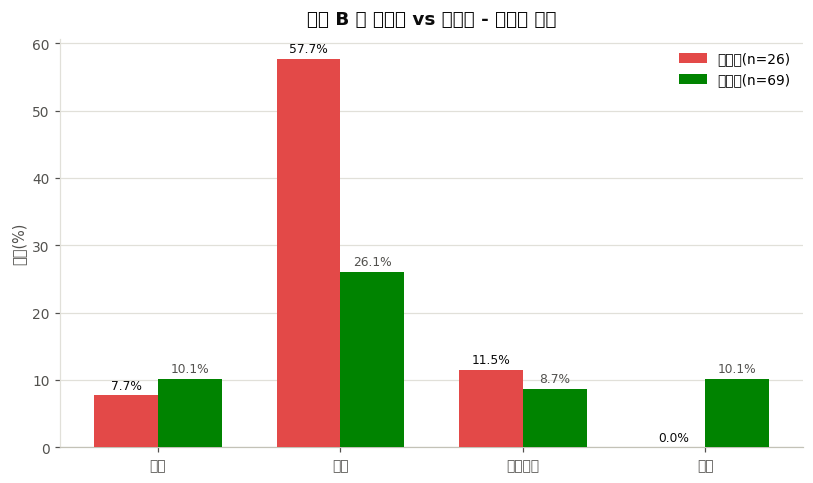

심각(serious) 비율: 철분제 96.2% vs 엽산제 97.1% - 거의 동일
입원 비율: 철분제 57.7% vs 엽산제 26.1% - 철분제가 두 배 이상 높음
장애 비율: 철분제 0.0% vs 엽산제 10.1% - 철분제는 0건, 엽산제는 존재

→ 같은 코드 B(조혈 관련 보충제) 안에서도 철분제가 엽산제보다 입원으로 이어지는 경우가 뚜렷이 많음 -
  '영양보충제라 다 비슷하게 순하다'는 인식과 달리, 철분제는 과다복용 시 위장관·전신 독성이 커서
  엽산제보다 급성기 관리(입원)가 필요한 경우가 많다는 것으로 해석 가능


In [14]:
folic = df[df['도출_ATC코드'] == 'B03BB01'].copy()  # 엽산제(경구)
print(f"철분제(B군): n={len(b)}, 엽산제: n={len(folic)}")
print()

metrics = ["is_fatal", "is_hospitalized", "is_life_threat", "is_disabling"]
metric_labels = ["사망", "입원", "생명위협", "장애"]
iron_rate = [b[m].mean() * 100 for m in metrics]
folic_rate = [folic[m].mean() * 100 for m in metrics]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
x = np.arange(len(metrics)); w = 0.35
ax.bar(x - w/2, iron_rate, w, label=f"철분제(n={len(b)})", color=C6_RED, zorder=3)
ax.bar(x + w/2, folic_rate, w, label=f"엽산제(n={len(folic)})", color=C4_GREEN, zorder=3)
ax.set_xticks(x); ax.set_xticklabels(metric_labels)
style_ax(ax, "코드 B 내 철분제 vs 엽산제 - 심각도 비교", None, "비율(%)")
ax.legend(frameon=False, fontsize=9)
for xi, (iv, fv) in enumerate(zip(iron_rate, folic_rate)):
    ax.text(xi - w/2, iv + 1, f"{iv:.1f}%", ha="center", fontsize=8, color=INK)
    ax.text(xi + w/2, fv + 1, f"{fv:.1f}%", ha="center", fontsize=8, color=INK2)
plt.tight_layout()
plt.show()

folic_serious = (folic['serious']=='Yes').mean()*100
iron_serious = (b['serious']=='Yes').mean()*100
iron_hosp = b['is_hospitalized'].mean()*100
folic_hosp = folic['is_hospitalized'].mean()*100
iron_dis = b['is_disabling'].mean()*100
folic_dis = folic['is_disabling'].mean()*100
print(f"심각(serious) 비율: 철분제 {iron_serious:.1f}% vs 엽산제 {folic_serious:.1f}% - 거의 동일")
print(f"입원 비율: 철분제 {iron_hosp:.1f}% vs 엽산제 {folic_hosp:.1f}% - 철분제가 두 배 이상 높음")
print(f"장애 비율: 철분제 {iron_dis:.1f}% vs 엽산제 {folic_dis:.1f}% - 철분제는 0건, 엽산제는 존재")
print()
print("→ 같은 코드 B(조혈 관련 보충제) 안에서도 철분제가 엽산제보다 입원으로 이어지는 경우가 뚜렷이 많음 -")
print("  '영양보충제라 다 비슷하게 순하다'는 인식과 달리, 철분제는 과다복용 시 위장관·전신 독성이 커서")
print("  엽산제보다 급성기 관리(입원)가 필요한 경우가 많다는 것으로 해석 가능")

## 11. 문헌 기반 보완 분석 - 라벨의 소아 중독 경고와 실제 데이터의 격차

In [15]:
print("이 노트북의 가장 중요한 발견은 '있는 데이터'가 아니라 '없는 데이터'입니다:")
print("라벨은 '6세 미만 소아의 우발적 과다복용이 치명적 중독의 주요 원인'이라고 명시하지만, 이 26건 중")
print("소아 사례는 0건입니다. 이 격차 자체를 문헌으로 짚어봅니다.")
print()
print("[1] 왜 라벨에 이 경고가 있는가")
print("철분 보충제는 흔한 가정상비약이면서, 1980년대~90년대 미국에서 소아의 철분제 섭취 신고가 크게")
print("늘고 노출 100건당 사망률도 함께 증가한 시기가 있었습니다. 당시 처방량 증가는 미미했던 반면")
print("일반의약품(OTC) 철분제 사용이 늘어난 것이 주된 배경으로 지목됩니다.")
print("출처: Berkovitch M, Matsui D, Lamm SH, Rosa F, Koren G. \"Recent increases in numbers and risk of")
print("      fatalities in young children ingesting iron preparations.\" Vet Hum Toxicol. 1994;36(1):")
print("      53-56. PMID 8154104. https://pubmed.ncbi.nlm.nih.gov/8154104/")
print()
print("      Michael JB, Sztajnkrycer MD. \"Deadly pediatric poisons: nine common agents that kill at")
print("      low doses.\" Emerg Med Clin North Am. 2004;22(4):1019-1050. PMID 15474780.")
print("      https://pubmed.ncbi.nlm.nih.gov/15474780/")
print()
print("[2] 규제 개입과 그 이후 - \"효과가 있었지만 계속되지는 않았다\"")
print("미국은 1997년부터 철분 함유 제품에 개별 포장(unit-dose packaging)을 의무화했고, 이 조치 이후")
print("소아의 철분 섭취·사망이 줄었다는 분석이 있습니다. 그런데 2003년, 건강기능식품 업계가 FDA의")
print("관할권을 문제 삼은 소송 끝에 이 규정 자체가 철회되었습니다. 즉 이 데이터(2015년 이후 보고 위주)에")
print("소아 사례가 없는 것을 \"포장 규제 덕분에 안전해졌다\"고 단순히 해석하기는 어렵고, 오히려 규제")
print("이력 자체가 유동적이었다는 점을 함께 봐야 합니다.")
print("출처: Tenenbein M. \"Unit-dose packaging of iron supplements and reduction of iron poisoning in")
print("      young children.\" Arch Pediatr Adolesc Med. 2005;159(6):557-560. PMID 15939855.")
print("      https://pubmed.ncbi.nlm.nih.gov/15939855/")
print()
print("[3] 그렇다면 왜 이 데이터에는 소아 사례가 0건인가 - \"소아가 안전하다\"는 뜻으로 읽으면 안 되는 이유")
print("소아의 약물 우발 섭취 사고는 미국에서 통상 병원이 아니라 중독관리센터(Poison Control)로 먼저")
print("전화가 걸려오고, 그중 상당수는 입원이나 처치 없이 가정에서 관찰만으로 종결됩니다. 실제로 미국")
print("독성학회(AAPCC)는 철분 섭취를 매우 흔한 상담 유형으로 보고 별도의 표준 대응 지침까지 마련해")
print("두었을 정도입니다 - 즉 소아 철분 섭취 사고 자체는 여전히 흔하게 \"발생\"하고 있을 가능성이 높습니다.")
print("그런데 이 노트북의 데이터는 FDA의 약물 이상사례 보고 시스템(FAERS)에서 온 것으로, 중독관리센터")
print("상담 기록과는 별개의 시스템입니다. 병원 이송이나 후유증 없이 종결된 소아 사고는 FAERS로 넘어오지")
print("않을 가능성이 크므로, \"이 26건 중 소아 사례가 0건\"이라는 사실은 \"소아가 위험하지 않다\"가 아니라")
print("\"이 데이터 소스가 그 위험을 관측하기에 적합하지 않다\"로 해석하는 것이 더 정확합니다. (여기에 더해")
print("표본 자체가 26건뿐이라는 점도 있습니다.)")
print("출처: Manoguerra AS, Erdman AR, Booze LL, et al. (American Association of Poison Control Centers).")
print("      \"Iron ingestion: an evidence-based consensus guideline for out-of-hospital management.\"")
print("      Clin Toxicol (Phila). 2005;43(6):553-570. PMID 16255338.")
print("      https://pubmed.ncbi.nlm.nih.gov/16255338/")
print()
print("[4] 그렇다면 이 데이터의 청소년/성인 과다복용 사례는 무엇을 의미하는가")
print("위 [3]과 별개로, 7번 섹션에서 확인한 16세의 의도적 과다복용(자살시도)과 59세 성인의 투여경로")
print("오류 사례는 \"이 FAERS 표본 안에 실제로 존재하는\" 신호입니다. 다만 이것이 \"소아보다 청소년·성인이")
print("더 위험하다\"는 비교 결론으로 이어지지는 않습니다 - 두 위험은 서로 다른 데이터 소스에 다른 비율로")
print("잡히므로, 이 표본 하나로 두 집단의 위험을 직접 비교할 수는 없습니다. 안전하게 말할 수 있는 것은")
print("\"청소년의 의도적 과다복용, 성인의 투여경로 오류도 이 성분의 실제 위험 중 하나\"라는 점까지입니다.")
print()
print("[5] 급성 철 중독의 임상 경과(왜 사망까지 이어졌는가)")
print("급성 철 중독은 초기 위장관 부식·출혈 이후 일시적으로 호전된 것처럼 보이는 잠복기를 거쳐, 이후")
print("대사성 산증과 간독성, 다장기부전으로 진행할 수 있습니다. 기전적으로는 철 이온이 세포 내")
print("미토콘드리아에 쌓여 산화적 인산화를 방해하고 자유라디칼·지질과산화를 일으키는 것이 핵심입니다.")
print("16세 사망 사례에서 관찰된 장천공·복막 내 공기(pneumoperitoneum)·다발성 장기부전은 이 경과와")
print("일치하는 소견입니다.")
print("출처: NCBI StatPearls. \"Iron Toxicity.\" https://www.ncbi.nlm.nih.gov/books/NBK459224/")
print()
print("[6] 약물 상호작용 (참조표에 이미 명시)")
print("철분제는 테트라사이클린계·퀴놀론계 항생제, 갑상선호르몬제(레보티록신) 등과 함께 복용하면 철이")
print("이들 약물과 결합(킬레이션)해 흡수를 방해할 수 있어, 2시간 이상 간격을 두고 복용하도록 권고됩니다")
print("(참조표의 '테트라사이클린계 항생제와는 2시간 간격 필요' 문구가 이를 반영).")

이 노트북의 가장 중요한 발견은 '있는 데이터'가 아니라 '없는 데이터'입니다:
라벨은 '6세 미만 소아의 우발적 과다복용이 치명적 중독의 주요 원인'이라고 명시하지만, 이 26건 중
소아 사례는 0건입니다. 이 격차 자체를 문헌으로 짚어봅니다.

[1] 왜 라벨에 이 경고가 있는가
철분 보충제는 흔한 가정상비약이면서, 1980년대~90년대 미국에서 소아의 철분제 섭취 신고가 크게
늘고 노출 100건당 사망률도 함께 증가한 시기가 있었습니다. 당시 처방량 증가는 미미했던 반면
일반의약품(OTC) 철분제 사용이 늘어난 것이 주된 배경으로 지목됩니다.
출처: Berkovitch M, Matsui D, Lamm SH, Rosa F, Koren G. "Recent increases in numbers and risk of
      fatalities in young children ingesting iron preparations." Vet Hum Toxicol. 1994;36(1):
      53-56. PMID 8154104. https://pubmed.ncbi.nlm.nih.gov/8154104/

      Michael JB, Sztajnkrycer MD. "Deadly pediatric poisons: nine common agents that kill at
      low doses." Emerg Med Clin North Am. 2004;22(4):1019-1050. PMID 15474780.
      https://pubmed.ncbi.nlm.nih.gov/15474780/

[2] 규제 개입과 그 이후 - "효과가 있었지만 계속되지는 않았다"
미국은 1997년부터 철분 함유 제품에 개별 포장(unit-dose packaging)을 의무화했고, 이 조치 이후
소아의 철분 섭취·사망이 줄었다는 분석이 있습니다. 그런데 2003년, 건강기능식품 업계가 FDA의
관할권을 문제 삼은 소송 끝에 이 규정 자체가 철회되었습니다. 즉 이 데이터(2015년 

## 12. 종합 인사이트 요약

- 정의: B군(철분제) = 도출_ATC코드 == "B03AA07"(Ferrous sulfate), 26건 - 코드 B(혈액 및 조혈기관용제)
  전체의 27.4%(제공 이미지 기준 26.6%와 근사). 표본이 지금까지 분석한 성분 중 가장 작아(n=26, 그마저도
  serious=No는 1건뿐) 대부분의 세부 통계 검정이 신뢰하기 어려움.
- 인체특성: 연령 확인 가능 17건 중 중앙값 66세로 나머지 전체(59.6세)와 큰 차이 없음(p=0.194, 유의하지
  않음). 여성 비율 65.4%로 나머지 전체(49.7%)보다 높게 나타나며, 철결핍성 빈혈이 여성(특히 가임기)에서
  더 흔하다는 임상적 배경과 방향은 일치하나 표본이 작아 확정할 수 없음.
- 심각도(핵심 발견): 다섯 개 지표 중 입원 비율(57.7% vs 34.3%, p=0.022)만 통계적으로 유의하게 높음 -
  철분제 관련 신고는 나머지 전체보다 입원으로 이어지는 경우가 뚜렷이 많음.
- 병용약물/투약사유: 병용약물수는 유의한 차이 없음(p=0.374). 적응증은 절반 이상이 '미기재'로, 처방
  치료제라기보다 건강기능식품처럼 자가 복용되는 경향을 시사.
- 급성 중독 신호(핵심 발견): 대표 반응에 '완결된 자살'과 '의도적 과다복용'이 등장하고, 청소년(16세)의
  의도적 과다복용→급성 간부전, 16세의 다발성 장기부전·장천공(B군 유일한 사망 사례), 59세 성인의
  투여경로 오류 사례가 확인됨. 반면 라벨이 명시적으로 경고하는 '6세 미만 소아의 우발적 과다복용'
  사례는 이 26건 중 단 하나도 없음 - 다만 이를 "소아는 상대적으로 안전하다"로 해석해서는 안 됨.
  소아 우발 섭취는 통상 FDA 이상사례 시스템이 아닌 중독관리센터로 먼저 신고되는 별개의 경로이며
  (11번 섹션 참고), 표본도 26건뿐이라 이 데이터는 애초에 그 위험을 관측하기에 적합한 도구가 아님.
- 같은 ATC코드(B) 내 비교: 엽산제와 비교하면 심각 비율은 거의 같지만(96.2% vs 97.1%), 입원 비율은
  철분제가 두 배 이상 높고(57.7% vs 26.1%), 장애 비율은 반대로 철분제가 0%로 더 낮음 - 같은 '조혈계
  보충제'라도 위험의 성격이 다름.
- 문헌 기반 보완: 소아 철분 중독은 응급의학·독성학 문헌에서 오래전부터 다뤄진 대표적 위험이며, 미국의
  개별 포장 의무화(1997년) 이후 소아 사망이 줄었다는 보고가 있으나, 이 규정은 2003년 소송 끝에
  철회되었음 - 이 데이터에 소아 사례가 없는 것을 "규제가 지금도 작동해서"로 단순히 볼 수는 없고,
  규제 이력 자체가 유동적이었다는 점을 함께 고려해야 함. 청소년의 의도적 과다복용은 애초에 소아
  안전 포장으로는 막을 수 없는 별개의 위험 영역.

(※ 11번 섹션에 인용한 문헌의 원문 링크(PubMed 등)는 해당 섹션에서 확인할 수 있습니다.)

결론: B군(철분제)은 표본이 극히 작아(n=26) 정량적 결론에는 한계가 크지만, 정성적으로는 뚜렷한 이야기가
있다. (i) 입원으로 이어지는 비율이 나머지 전체보다 유의하게 높고, (ii) 이 FAERS 표본 안에서는 청소년의
의도적 과다복용과 성인의 투여경로 오류가 실제 중증 사례로 확인되지만, 이것이 "소아 우발 중독보다 더
중요한 위험"이라는 뜻은 아니다 - 소아 우발 중독은 별개의 신고 경로(중독관리센터)로 주로 잡히기 때문에
이 데이터셋에 없다고 해서 실재하지 않는 것이 아니며, 라벨의 소아 경고는 여전히 유효하게 다뤄야 한다.
(iii) 같은 조혈계 보충제인 엽산제보다 급성기 관리(입원)가 필요한 경우가 훨씬 많다. 관리 우선순위는
① 소아 손이 닿지 않는 보관(데이터에는 없지만 문헌상 확립된 위험), ② 청소년 정신건강 맥락에서의
접근성 관리, ③ 성인 사용자 대상의 정확한 복용법(용량·간격) 안내, 세 가지 모두를 함께 다루는 데
있다.

## 13. 소비자를 위한 요약 - 이 약을 복용하기 전에 알아둘 점

(※ 위 분석 결과를 일반 소비자가 읽기 쉽게 풀어 쓴 것입니다. 표본이 매우 작은 성분이라 아래 내용 중
일부는 데이터보다 의학 문헌에 더 크게 의존하고 있습니다. 구체적인 판단은 의사·약사와 상의하세요.)

- **"영양제니까 안전하다"는 생각은 위험할 수 있습니다.** 철분제는 정해진 용량을 초과해서 먹으면 짧은
  시간 안에 위장관 손상, 간 손상, 심한 경우 다발성 장기부전으로 이어질 수 있는 성분입니다. 실제로 이
  데이터에서 확인된 중증 사례들은 모두 정해진 용량을 넘겨 먹은 경우였습니다.
- **라벨 경고: "소아(6세 미만)의 우발적 과다복용은 치명적 중독의 주요 원인"입니다.** 이 성인용 정제를
  소아에게 임의로 먹이지 말고, 정제 낱개 포장을 뜯어서 통째로 보관하지 말고 원래 포장 그대로 손이
  닿지 않는 곳에 두세요. (소아의 빈혈 치료가 필요하다면 이 성인용 정제가 아니라 별도의 소아용 제형·
  용량에 대해 소아과와 상담하세요.)
- **청소년도 주의가 필요합니다(추가 인사이트).** 이 데이터에서는 16세 청소년이 정해진 용량을 크게
  초과해 복용한 사례가 확인되었습니다. 청소년 본인이 복용 중이라면 정해진 용량만 먹도록 챙겨주시고,
  혹시 힘든 시기를 보내고 있다면 혼자 두지 말고 신뢰할 수 있는 어른과 이야기하거나 1393(자살예방상담
  전화)에 언제든 연락할 수 있다는 것도 알려주세요.
- **혹시라도 다량을 삼켰다면(본인이든 자녀든) 지체하지 말고 응급실이나 중독관리센터에 연락하세요.**
  처음에는 속이 좀 불편한 정도로 괜찮아 보여도, 몇 시간 뒤 갑자기 악화되는 경우가 있어 "괜찮아 보이니
  괜찮겠지"라고 넘기면 안 됩니다.
- **심한 복통이나 검붉은 대변이 있으면 즉시 복용을 멈추고 상담하세요.** 철분제를 먹으면 대변이 검게
  변하는 것 자체는 정상이지만, 여기에 심한 복통이나 진짜 혈변(끈적하고 냄새가 심한 검은 변)이 같이
  나타나면 다른 문제일 수 있습니다.
- **다른 약과 함께 먹을 때는 시간 간격을 두세요.** 특히 테트라사이클린·퀴놀론 계열 항생제나 갑상선
  호르몬제는 철분과 같이 먹으면 그 약의 흡수가 방해받을 수 있어, 최소 2시간 이상 간격을 두고
  복용하는 것이 권장됩니다.